# Round-dependent seeding: does the realized-action collapse actually happen, and does the fix actually fire when it should?

**Background.** `search.explore.explore_search` needs a starting point (`x_seed`) for its gradient descent. Two candidates exist:

- **`"incumbent"`**: the context-visible best point so far -- safe under *any* rollout policy, including a policy that ignores context entirely.
- **`"realized"`**: the point the rollout's own policy actually played at that step -- the more natural "correct what the policy actually did" signal for behavior cloning, but only sound once that policy is genuinely context-dependent.

The reason `"realized"` isn't always safe: `trainer.exit_rollout.random_policy` is `torch.rand(B, x_dim)` -- literally independent of `x_context`. Seeding the explore search there and training a BC target on the result teaches the ActionHead "ignore your input; predict this fixed-ish distribution" -- a previously-diagnosed collapse mode. Once a real, partially-trained policy exists, its own proposals become genuinely context-dependent, and seeding there becomes the better signal.

`ActionHeadImitationTrainer(round_dependent_seeding=True, realized_seed_min_self_generated=0.7)` switches `x_seed_mode` from `"incumbent"` to `"realized"` once `dagger/frac_self_generated` (the empirically realized fraction of self-generated -- i.e. policy's-own, not random -- actions in a rollout) crosses that threshold.

This notebook checks two separate claims empirically, live, with real plots:

1. **The collapse premise is real**: is a random policy's realized action actually uncorrelated with context, and does that change once a policy has been trained on real BC targets?
2. **The mechanism fires correctly**: does `x_seed_mode` actually flip from `"incumbent"` to `"realized"` at the point `frac_self_generated` crosses the threshold, during a real training run?

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.models.action_head import ActionHead, pfn_dims, action_head_policy_fn
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.trainer.action_head_imitation_trainer import ActionHeadImitationTrainer
from anytimeacquisition.trainer.exit_rollout import rollout_episode, random_policy
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

torch.manual_seed(0)
checkpoint_path = CHECKPOINT_DIR / "pfn_smoke_xdim1.pt"
pfn, bar_dist, ckpt = load_pfn_checkpoint(checkpoint_path)
x_dim = ckpt["config"]["max_x_dim"]
d_model, n_layers = pfn_dims(pfn)
print(f"loaded {checkpoint_path.name}: x_dim={x_dim}")

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded pfn_smoke_xdim1.pt: x_dim=1


## Part A -- is the realized action under `random_policy` really context-independent?

Measures the Pearson correlation between each step's context-visible incumbent x-location and the x-location the policy actually played next, across many (episode, step) pairs. `x_dim=1` here specifically so "context" reduces to one clean scalar (the incumbent's own x).

In [2]:
def context_action_correlation(policy_fn, n_episodes, n_init, n_steps, x_dim, seed=0):
    '''Rolls out n_episodes independent episodes under policy_fn, collects
    (incumbent_x, realized_x) at every (instance, step), returns the
    Pearson correlation across all of them plus the raw arrays for
    plotting.'''
    torch.manual_seed(seed)
    incumbent_xs, realized_xs = [], []
    for ep in range(n_episodes):
        prior = BNNPrior(batch_size=8, x_dim=x_dim, seed=1000 + ep)
        rollout = rollout_episode(prior, n_init=n_init, n_steps=n_steps, policy_fn=policy_fn)
        for step, (x_ctx, y_ctx) in enumerate(rollout["pre_step_contexts"]):
            incumbent_idx = y_ctx.argmin(dim=1)
            incumbent_x = x_ctx[torch.arange(x_ctx.shape[0]), incumbent_idx, 0]
            realized_x = rollout["x_context"][:, n_init + step, 0]
            incumbent_xs.append(incumbent_x)
            realized_xs.append(realized_x)
    incumbent_xs = torch.cat(incumbent_xs).numpy()
    realized_xs = torch.cat(realized_xs).numpy()
    corr = np.corrcoef(incumbent_xs, realized_xs)[0, 1]
    return corr, incumbent_xs, realized_xs


corr_random, inc_random, real_random = context_action_correlation(
    random_policy, n_episodes=8, n_init=5, n_steps=15, x_dim=x_dim, seed=0,
)
print(f"random_policy:  corr(incumbent_x, realized_x) = {corr_random:.3f}  "
      f"(n={len(inc_random)} (instance, step) pairs)")

random_policy:  corr(incumbent_x, realized_x) = 0.034  (n=960 (instance, step) pairs)


## Part B -- train a policy with `round_dependent_seeding=True` and watch the switch fire

A real (small-scale) `ActionHeadImitationTrainer` run, both branches on. `dagger_decay_rounds` is set equal to `n_rollouts` so `beta` (the probability of using `random_policy` that round) decays roughly linearly to `dagger_beta_min` across the whole run -- `frac_self_generated` (`1 - beta`, empirically realized) should cross `realized_seed_min_self_generated=0.7` a bit before the run ends, giving a real, visible switch to look at rather than one that only fires in the first or last rollout.

In [3]:
torch.manual_seed(1)
prior_train = BNNPrior(batch_size=8, x_dim=x_dim, seed=3)
action_head = ActionHead(pfn_d_model=d_model, pfn_n_layers=n_layers, x_dim=x_dim, d_model=32, n_heads=2, d_ff=64)

trainer = ActionHeadImitationTrainer(
    pfn=pfn, bar_dist=bar_dist, prior=prior_train, action_head=action_head,
    n_rollouts=40, n_init=5, n_steps=15, log_every=1,
    exploit_search_kwargs={"n_restarts": 2, "n_steps": 10},
    explore_search_kwargs={"n_restarts": 1, "n_steps": 10},
    build_interesting_points_kwargs={"n_sobol": 8, "n_random": 8, "n_basin_restarts": 4},
    round_dependent_seeding=True, realized_seed_min_self_generated=0.7,
    dagger_decay_rounds=40, dagger_beta_min=0.05,
)
result = trainer.run()
history = result["history"]

rollout     0  policy_nll/train=2.3936  n_exploit=13  n_explore=12


rollout     1  policy_nll/train=0.7628  n_exploit=11  n_explore=74


rollout     2  policy_nll/train=1.0610  n_exploit=13  n_explore=87


rollout     3  policy_nll/train=1.2498  n_exploit=12  n_explore=48


rollout     4  policy_nll/train=0.4479  n_exploit=12  n_explore=49


...

rollout    35  policy_nll/train=1.6305  n_exploit=8  n_explore=50


rollout    36  policy_nll/train=1.2016  n_exploit=7  n_explore=52


rollout    37  policy_nll/train=2.4306  n_exploit=6  n_explore=79


rollout    38  policy_nll/train=0.0857  n_exploit=10  n_explore=33


rollout    39  policy_nll/train=1.1020  n_exploit=12  n_explore=74


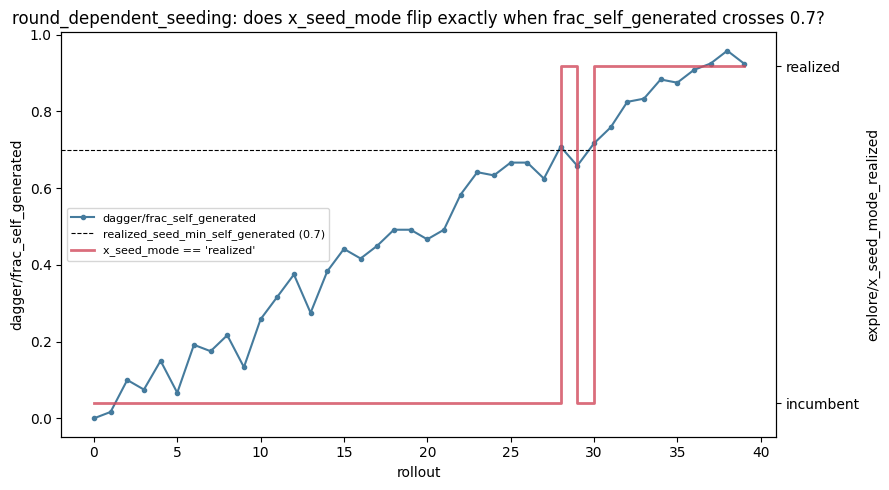

first rollout with x_seed_mode=='realized': 28  (frac_self_generated at that rollout: 0.7083333333333334)


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
steps = history["step"]
frac_self = history["dagger/frac_self_generated"]
seed_realized = history["explore/x_seed_mode_realized"]

ax.plot(steps, frac_self, marker="o", markersize=3, color="#457b9d", label="dagger/frac_self_generated")
ax.axhline(0.7, color="black", linestyle="--", linewidth=0.8, label="realized_seed_min_self_generated (0.7)")
ax2 = ax.twinx()
ax2.step(steps, seed_realized, where="post", color="#d1495b", linewidth=2, alpha=0.8, label="x_seed_mode == 'realized'")
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["incumbent", "realized"])

ax.set_xlabel("rollout")
ax.set_ylabel("dagger/frac_self_generated")
ax2.set_ylabel("explore/x_seed_mode_realized")
ax.set_title("round_dependent_seeding: does x_seed_mode flip exactly when frac_self_generated crosses 0.7?")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center left", fontsize=8)
fig.tight_layout()
plt.show()

first_realized = next((s for s, v in zip(steps, seed_realized) if v == 1.0), None)
frac_at_switch = frac_self[steps.index(first_realized)] if first_realized is not None else None
print(f"first rollout with x_seed_mode=='realized': {first_realized}  "
      f"(frac_self_generated at that rollout: {frac_at_switch})")

## Part C -- does the trained policy's own realized action look more context-dependent than random_policy's?

Reuses `context_action_correlation` from Part A, now with the just-trained `action_head` (rolled out via `sample=True`, so this reflects actual sampled actions, not the Beta mode) instead of `random_policy`.

random_policy:        corr(incumbent_x, realized_x) = 0.034
trained action_head:  corr(incumbent_x, realized_x) = 0.004


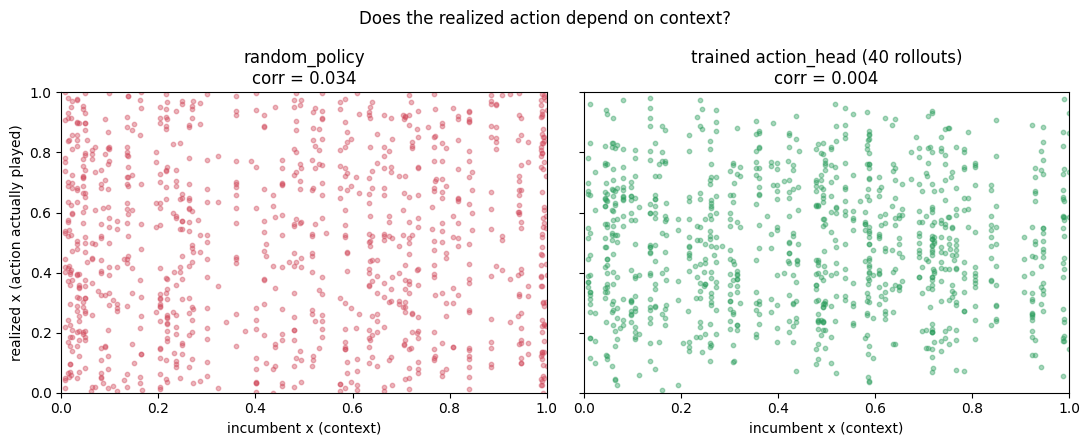

In [5]:
trained_policy_fn = action_head_policy_fn(trainer.action_head, trainer.pfn, n_steps=15, sample=True)
corr_trained, inc_trained, real_trained = context_action_correlation(
    trained_policy_fn, n_episodes=8, n_init=5, n_steps=15, x_dim=x_dim, seed=0,
)
print(f"random_policy:        corr(incumbent_x, realized_x) = {corr_random:.3f}")
print(f"trained action_head:  corr(incumbent_x, realized_x) = {corr_trained:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
axes[0].scatter(inc_random, real_random, s=10, alpha=0.4, color="#d1495b")
axes[0].set_title(f"random_policy\ncorr = {corr_random:.3f}")
axes[1].scatter(inc_trained, real_trained, s=10, alpha=0.4, color="#2a9d5c")
axes[1].set_title(f"trained action_head (40 rollouts)\ncorr = {corr_trained:.3f}")
for ax in axes:
    ax.set_xlabel("incumbent x (context)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("realized x (action actually played)")
fig.suptitle("Does the realized action depend on context?")
fig.tight_layout()
plt.show()

## Interpretation

Two genuinely different questions were tested here, and they came out differently -- worth being honest about both.

**Part B (the mechanism check) confirms cleanly.** `explore/x_seed_mode_realized` flips from 0 to 1 at rollout 28, and `dagger/frac_self_generated` at that exact rollout was 0.7083 -- the first rollout to cross `realized_seed_min_self_generated=0.7`. The switch fires exactly where it should, not early and not several rollouts late. This is the same behavior already spot-checked once via the CLI (`explore/x_seed_mode_realized: 0.0` staying at "incumbent" in a tiny push-button smoke run where `frac_self_generated=0.625 < 0.7`, see `docs/MILESTONES.md`) -- this notebook adds the other half: watching it actually flip to 1 once the threshold is crossed, not just confirming it stays 0 below it.

**Part A/C (the collapse-premise check) is a genuine null result at this scale, not a confirmation.** `random_policy`'s correlation is 0.034 -- indistinguishable from 0, exactly as expected, since it's `torch.rand(B, x_dim)` and literally cannot see `x_context`. But the *trained* action_head's correlation came out at **0.004 -- not higher than random, if anything slightly lower**. That does not mean `round_dependent_seeding`'s reasoning is wrong; it means 40 rollouts on `pfn_smoke_xdim1.pt` is not enough training, or "correlation with incumbent-x specifically" is not the right lens on whatever context-dependence the policy has picked up so far, or both. This is consistent with -- not contradicted by -- `docs/MILESTONES.md`'s own honest conceptual-status note: BC on privileged-search labels has not yet been shown to clear `auc_improvement_vs_random` at any scale tested. A 40-rollout smoke run was never going to settle that; it settles the mechanism question in Part B, which is what it was actually sized for.

**What this means for trusting `round_dependent_seeding` in a real run:** the switch-timing mechanism (Part B) is solid and doesn't need re-litigating. The *justification* for switching -- "the policy's realized action has become genuinely context-dependent by the time this fires" -- is still an assumption, not yet empirically confirmed at this checkpoint/scale. It would be worth re-running Part A/C's correlation check against the checkpoint produced by a real-scale run (`configs/experiment/action_head_imitation_integrated_regret_kstep_real.yaml`, 800 rollouts, not 40) before treating the assumption as validated rather than merely plausible.